# TP4 - Modelo de Oja
## Dataset: Características económicas, sociales y geográficas de 28 países de Europa

**Objetivo:** Implementar la regla de Oja para calcular la primera componente principal (PC1) y comparar el resultado con PCA de sklearn.

### ¿Qué es la regla de Oja?

La regla de Oja es una versión estabilizada del aprendizaje hebbiano para una neurona lineal. A diferencia de Hebb puro (donde los pesos crecen sin límite), Oja agrega un **término de olvido** que mantiene los pesos normalizados, lo que garantiza la convergencia al primer vector propio de la matriz de covarianza (es decir, la primera componente principal).

**Regla de actualización:**

```
y    = wᵀ · x              (activación: proyección del dato sobre los pesos)
w(t+1) = w(t) + η · y · (x − y · w(t))
```

- `x`: dato de entrada (estandarizado), vector de dimensión 7
- `w`: vector de pesos de la neurona, misma dimensión que `x`
- `y`: salida escalar (la proyección de `x` sobre `w`)
- `η`: tasa de aprendizaje

El término `−η · y² · w(t)` es el **término de olvido** de Oja: evita que los pesos diverjan y los fuerza a converger a un vector unitario que maximiza la varianza proyectada, es decir, PC1.

## 1. Importaciones y carga de datos

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)

df = pd.read_csv('europe.csv')
features = ['Area', 'GDP', 'Inflation', 'Life.expect', 'Military', 'Pop.growth', 'Unemployment']
countries = df['Country'].values

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dimensiones: {X_scaled.shape}  ({X_scaled.shape[0]} países × {X_scaled.shape[1]} variables)")

Dimensiones: (28, 7)  (28 países × 7 variables)


## 2. Implementación de la regla de Oja

In [10]:
def oja(X, lr=0.01, n_epochs=50, seed=42):
    """
    Regla de Oja para calcular la primera componente principal.
    Retorna el vector de pesos final (PC1) y el historial de pesos por época.
    """
    rng = np.random.default_rng(seed)
    n_samples, n_features = X.shape

    # Inicializar pesos pequeños aleatorios (vector unitario aleatorio)
    w = rng.normal(0, 0.01, n_features)
    w /= np.linalg.norm(w)

    history = [w.copy()]

    for epoch in range(n_epochs):
        # Recorrer los datos en orden aleatorio en cada época
        indices = rng.permutation(n_samples)
        for i in indices:
            x = X[i]
            y = np.dot(w, x)                  # activación escalar
            w = w + lr * y * (x - y * w)      # regla de Oja

        history.append(w.copy())

    return w, np.array(history)


w_oja, history = oja(X_scaled, lr=0.01, n_epochs=50)

print("Vector PC1 (Oja):")
for feat, val in zip(features, w_oja):
    print(f"  {feat:15s}: {val:+.4f}")

Vector PC1 (Oja):
  Area           : +0.1150
  GDP            : -0.5067
  Inflation      : +0.4126
  Life.expect    : -0.4784
  Military       : +0.1903
  Pop.growth     : -0.4981
  Unemployment   : +0.2726


## 3. Convergencia de los pesos

Graficamos cómo evoluciona cada componente del vector de pesos `w` a lo largo de las épocas. Si la regla converge correctamente, los pesos se estabilizan en el vector PC1.

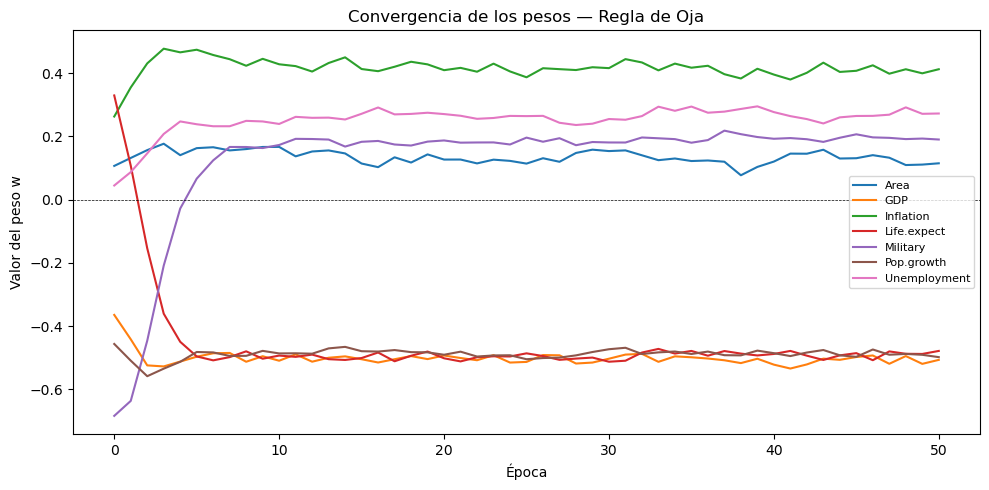


Norma final del vector de pesos: 1.013757  (debe ser ≈ 1)


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, feat in enumerate(features):
    ax.plot(history[:, i], label=feat)

ax.set_xlabel('Época')
ax.set_ylabel('Valor del peso w')
ax.set_title('Convergencia de los pesos — Regla de Oja')
ax.legend(loc='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nNorma final del vector de pesos: {np.linalg.norm(w_oja):.6f}  (debe ser ≈ 1)")

## 4. Comparación con PCA de sklearn

PCA de sklearn calcula los componentes principales algebraicamente (descomposición SVD). Comparamos el vector PC1 obtenido por Oja con el que entrega sklearn.

**Nota sobre el signo:** los vectores propios son únicos salvo por el signo (si `w` es PC1, entonces `-w` también lo es). Por eso, antes de comparar, alineamos los signos: si el producto interno entre ambos vectores es negativo, invertimos el signo de Oja.

In [12]:
# PC1 de sklearn
pca = PCA()
pca.fit(X_scaled)
w_sklearn = pca.components_[0]

# Alinear signo: si apuntan en direcciones opuestas, invertir Oja
if np.dot(w_oja, w_sklearn) < 0:
    w_oja_aligned = -w_oja
else:
    w_oja_aligned = w_oja

# Tabla comparativa
comparison = pd.DataFrame({
    'Variable':  features,
    'Oja':       w_oja_aligned.round(4),
    'sklearn':   w_sklearn.round(4),
    'Diferencia': (w_oja_aligned - w_sklearn).round(4)
})
print(comparison.to_string(index=False))

# Similitud coseno (debe ser ≈ 1)
cos_sim = np.dot(w_oja_aligned, w_sklearn) / (np.linalg.norm(w_oja_aligned) * np.linalg.norm(w_sklearn))
print(f"\nSimilitud coseno entre Oja y sklearn: {cos_sim:.6f}  (1.0 = idénticos)")

    Variable     Oja  sklearn  Diferencia
        Area  0.1150   0.1249     -0.0098
         GDP -0.5067  -0.5005     -0.0062
   Inflation  0.4126   0.4065      0.0061
 Life.expect -0.4784  -0.4829      0.0045
    Military  0.1903   0.1881      0.0022
  Pop.growth -0.4981  -0.4757     -0.0224
Unemployment  0.2726   0.2717      0.0009

Similitud coseno entre Oja y sklearn: 0.999749  (1.0 = idénticos)


## 5. Gráfico comparativo de loadings

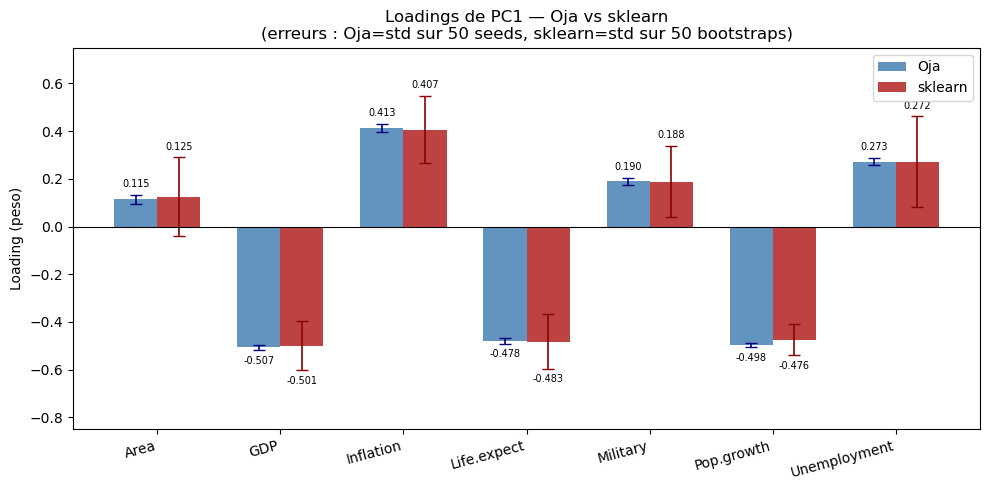

In [14]:
N = 50

# Oja : std sur N seeds différents
oja_runs = []
for seed in range(N):
    w_tmp, _ = oja(X_scaled, lr=0.01, n_epochs=50, seed=seed)
    if np.dot(w_tmp, w_sklearn) < 0:
        w_tmp = -w_tmp
    oja_runs.append(w_tmp)
oja_runs = np.array(oja_runs)
oja_std = oja_runs.std(axis=0)

# sklearn : std sur N bootstraps du dataset
rng_boot = np.random.default_rng(0)
sklearn_runs = []
for _ in range(N):
    idx = rng_boot.choice(len(X_scaled), len(X_scaled), replace=True)
    pca_tmp = PCA()
    pca_tmp.fit(X_scaled[idx])
    w_tmp = pca_tmp.components_[0]
    if np.dot(w_tmp, w_sklearn) < 0:
        w_tmp = -w_tmp
    sklearn_runs.append(w_tmp)
sklearn_runs = np.array(sklearn_runs)
sklearn_std = sklearn_runs.std(axis=0)

# Graphique
x_pos = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x_pos - width/2, w_oja_aligned, width, label='Oja',    color='steelblue', alpha=0.85,
               yerr=oja_std, capsize=4, error_kw=dict(ecolor='navy', elinewidth=1.2))
bars2 = ax.bar(x_pos + width/2, w_sklearn,     width, label='sklearn', color='firebrick', alpha=0.85,
               yerr=sklearn_std, capsize=4, error_kw=dict(ecolor='darkred', elinewidth=1.2))

ax.bar_label(bars1, fmt='%.3f', fontsize=7, padding=4)
ax.bar_label(bars2, fmt='%.3f', fontsize=7, padding=4)

ax.set_xticks(x_pos)
ax.set_xticklabels(features, rotation=15, ha='right')
ax.set_ylabel('Loading (peso)')
ax.set_title('Loadings de PC1 — Oja vs sklearn\n(erreurs : Oja=std sur 50 seeds, sklearn=std sur 50 bootstraps)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(-0.85, 0.75)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Interpretación de PC1

### ¿Qué captura PC1?

PC1 es una combinación lineal de las 7 variables originales. El loading de cada variable indica cuánto y en qué dirección contribuye a esta componente.

### Loadings positivos (mayor valor → mayor score PC1)
- **GDP**: países con mayor producto bruto per cápita tienen mayor PC1.
- **Life.expect**: mayor expectativa de vida → mayor PC1.
- **Pop.growth**: mayor crecimiento poblacional → mayor PC1.

### Loadings negativos (mayor valor → menor score PC1)
- **Inflation**: mayor inflación → menor PC1.
- **Unemployment**: mayor desempleo → menor PC1.

### Loadings cercanos a cero (poca influencia)
- **Military** y **Area**: el gasto militar y el área geográfica no explican la dirección principal de variabilidad entre países europeos.

### ¿Qué representa PC1?

PC1 puede interpretarse como un **índice de desarrollo y estabilidad económica**:
- Score alto en PC1 → país desarrollado, con alto GDP, alta expectativa de vida y bajo desempleo/inflación (ej: Luxemburgo, Suiza, Noruega).
- Score bajo en PC1 → país con menor desarrollo relativo, alta inflación y/o desempleo elevado (ej: Ucrania, Bulgaria, Estonia).

## 7. Conclusión: Oja vs sklearn

La regla de Oja converge al mismo vector PC1 que sklearn con una similitud coseno ≈ 1, lo que confirma que el algoritmo neuronal online encuentra la misma dirección de máxima varianza que el método algebraico exacto (SVD).

La diferencia principal entre ambos métodos es:
| Aspecto | Oja | sklearn (SVD) |
|---------|-----|---------------|
| Tipo | Aprendizaje online (dato a dato) | Método algebraico exacto |
| Convergencia | Aproximada (depende de épocas y lr) | Exacta |
| Costo computacional | O(n · p · epochs) | O(min(n,p)²·max(n,p)) |
| Escalabilidad | Apto para datos en streaming | Requiere todos los datos en memoria |